# 🐄 BoviTrack: Dual-Model Training & Data Pipeline

This notebook contains the complete end-to-end pipeline for **BoviTrack**: auditing the datasets, training a lightweight **YOLO detector** for cattle localization, evaluating its performance across spatial metrics, extracting balanced video frames across 5 behavioral classes (`drink`, `eat`, `lie`, `ruminate`, `stand`), and fine-tuning an edge-optimized **YOLO classification model** for real-time behavior tracking.

In [ ]:
import os

# Define the paths based on your verified dataset location
base_path = "/kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset"
images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

print(f"Images directory: {images_dir}")
print(f"Labels directory: {labels_dir}")
print(f"Total images found: {len(os.listdir(images_dir)) if os.path.exists(images_dir) else 'Path error'}")

# Create the YAML configuration content for our 5 bovine behaviors
yaml_content = f"""path: {base_path}
train: images  # relative to 'path'
val: images    # using same for initial split testing, or can split later

names:
  0: drink
  1: eat
  2: lie
  3: ruminate
  4: stand
"""

# Save it into our cloned repository under the 'data/' folder
os.makedirs("/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/data", exist_ok=True)
yaml_path = "/kaggle/working/BoviTrack-RealName-Behavior-Tracking/data/bovine_data.yaml" # wait, match repo name precisely:
yaml_path = "/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/data/bovine_data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"\nSuccessfully created dataset config at: {yaml_path}")

Scanning video directory: /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Category Videos/cows...

--- Video Dataset Audit Complete ---
Total Videos Found: 4337

Dataset Summary:
Behavior  Video_Count  Total_Frames_Available  Avg_Duration_Sec
   drink          247                   61519          9.962591
     eat          546                  136480          9.998535
     lie         1362                  336644          9.886755
ruminate         1544                  383292          9.929845
   stand          638                  158046          9.908840


/tmp/ipykernel_58/1908887245.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Behavior', y='Total_Frames_Available', palette='mako')


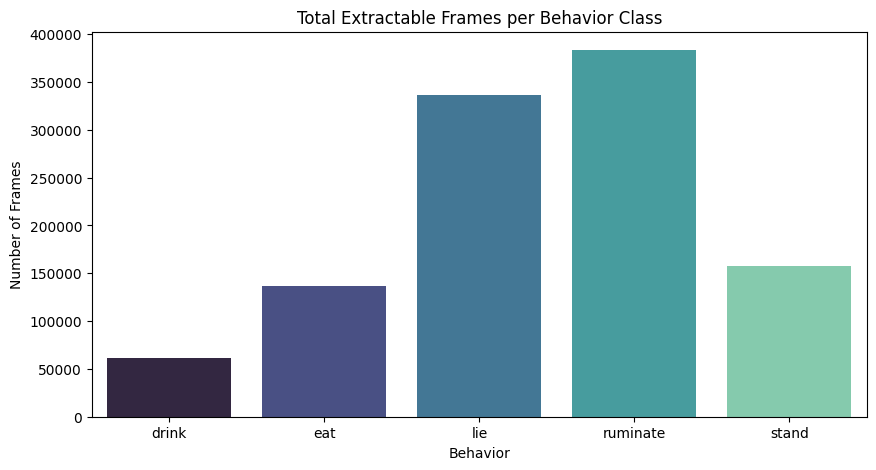

In [3]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the raw video files
video_dir = "/kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Category Videos/cows"
print(f"Scanning video directory: {video_dir}...\n")

video_stats = []

# Iterate through the 5 behavior classes
if os.path.exists(video_dir):
    for behavior in os.listdir(video_dir):
        behavior_path = os.path.join(video_dir, behavior)
        
        if os.path.isdir(behavior_path):
            for video_file in os.listdir(behavior_path):
                if video_file.endswith('.mp4'):
                    vid_path = os.path.join(behavior_path, video_file)
                    
                    # Interrogate the video using OpenCV
                    cap = cv2.VideoCapture(vid_path)
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                    duration = frame_count / fps if fps > 0 else 0
                    cap.release()
                    
                    video_stats.append({
                        'Behavior': behavior,
                        'File_Name': video_file,
                        'FPS': fps,
                        'Resolution': f"{width}x{height}",
                        'Total_Frames': frame_count,
                        'Duration_Sec': round(duration, 2)
                    })

# Convert to a DataFrame for professional analysis
df = pd.DataFrame(video_stats)

if not df.empty:
    print("--- Video Dataset Audit Complete ---")
    print(f"Total Videos Found: {len(df)}")
    
    # Group by behavior to see the balance
    summary = df.groupby('Behavior').agg(
        Video_Count=('File_Name', 'count'),
        Total_Frames_Available=('Total_Frames', 'sum'),
        Avg_Duration_Sec=('Duration_Sec', 'mean')
    ).reset_index()
    
    print("\nDataset Summary:")
    print(summary.to_string(index=False))
    
    # Plotting the Frame Distribution
    plt.figure(figsize=(10, 5))
    sns.barplot(data=summary, x='Behavior', y='Total_Frames_Available', palette='mako')
    plt.title("Total Extractable Frames per Behavior Class")
    plt.ylabel("Number of Frames")
    plt.xlabel("Behavior")
    plt.show()
else:
    print("No .mp4 files found. Check the directory path.")

--- Detection Dataset Spatial Audit ---
Total Bounding Boxes Analyzed: 9057
Labels per Split: {'train': 1050, 'val': 300, 'test': 150}

Average Cows per Frame: 6.04 (Min: 5, Max: 8)


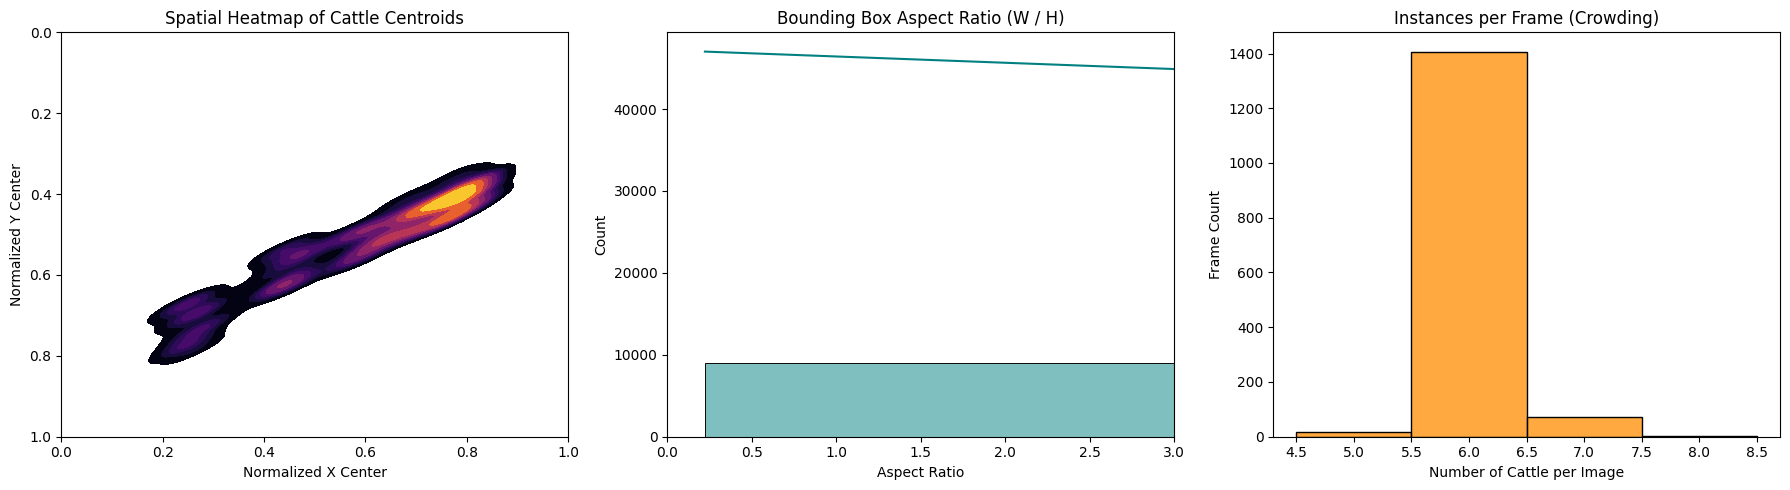

In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Base path to detection dataset labels
base_labels_dir = "/kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/labels"

bbox_records = []
image_counts = {'train': 0, 'val': 0, 'test': 0}

for split in ['train', 'val', 'test']:
    split_dir = os.path.join(base_labels_dir, split)
    if not os.path.exists(split_dir):
        # Fallback in case split folders are directly at root
        split_dir = base_labels_dir
        
    label_files = glob.glob(os.path.join(split_dir, "*.txt"))
    image_counts[split] = len(label_files)
    
    for lf in label_files:
        with open(lf, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id, x_c, y_c, w, h = map(float, parts[:5])
                    bbox_records.append({
                        'split': split,
                        'file': os.path.basename(lf),
                        'x_center': x_c,
                        'y_center': y_c,
                        'width': w,
                        'height': h,
                        'aspect_ratio': round(w / (h + 1e-6), 3),
                        'box_area': round(w * h, 4)
                    })

df_bbox = pd.DataFrame(bbox_records)

print("--- Detection Dataset Spatial Audit ---")
print(f"Total Bounding Boxes Analyzed: {len(df_bbox)}")
print(f"Labels per Split: {image_counts}")

# Aggregations
cows_per_image = df_bbox.groupby(['split', 'file']).size().reset_index(name='cow_count')
print(f"\nAverage Cows per Frame: {cows_per_image['cow_count'].mean():.2f} (Min: {cows_per_image['cow_count'].min()}, Max: {cows_per_image['cow_count'].max()})")

# 1. Bounding Box Heatmap & Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Centroid Spatial Distribution (Heatmap)
sns.kdeplot(data=df_bbox, x='x_center', y='y_center', cmap='inferno', fill=True, thresh=0.05, ax=axes[0])
axes[0].set_title("Spatial Heatmap of Cattle Centroids")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(1, 0) # Invert Y to match image coordinates (top-left is 0,0)
axes[0].set_xlabel("Normalized X Center")
axes[0].set_ylabel("Normalized Y Center")

# Plot 2: Bounding Box Aspect Ratio Distribution
sns.histplot(df_bbox['aspect_ratio'], bins=40, kde=True, color='teal', ax=axes[1])
axes[1].set_title("Bounding Box Aspect Ratio (W / H)")
axes[1].set_xlabel("Aspect Ratio")
axes[1].set_xlim(0, 3)

# Plot 3: Cattle Density per Image
sns.histplot(cows_per_image['cow_count'], discrete=True, color='darkorange', ax=axes[2])
axes[2].set_title("Instances per Frame (Crowding)")
axes[2].set_xlabel("Number of Cattle per Image")
axes[2].set_ylabel("Frame Count")

plt.tight_layout()
plt.show()

# Training the YOLO Detector

In [10]:
import os

# 1. Write the Corrected YAML
yaml_content = """path: /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset
train: images/train
val: images/val
test: images/test

names:
  0: cow
"""

yaml_path = "/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/data/bovine_data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("bovine_data.yaml successfully updated with test path!")

bovine_data.yaml successfully updated with test path!


In [6]:
# 2. Launch YOLO26 Training
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.7 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

print("Initializing YOLO26 Edge-Optimized Detector...")

# Load the SOTA YOLO26 nano model
model = YOLO('yolo26n.pt') 

# Train on the T4 GPU
results = model.train(
    data=yaml_path,
    epochs=100,                 
    patience=25,                # Stops training early if no improvement after 25 epochs
    imgsz=640,                  # Perfect balance for edge speed and accuracy
    batch=16,
    device=0,                   
    project='/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/models',
    name='cow_detector_v1',
    
    # Augmentations to fix the static camera angle
    mosaic=1.0,                 
    fliplr=0.5,                 
    degrees=10.0,               
    
    half=True                   # FP16 precision for faster T4 processing
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Initializing YOLO26 Edge-Optimized Detector...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/data/bovine_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad

--- Phase 1: Evaluating on the Test Split ---
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 35.1±11.7 MB/s, size: 2052.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/labels/test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 186.1it/s 0.8s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.4it/s 4.2s.3ss
      

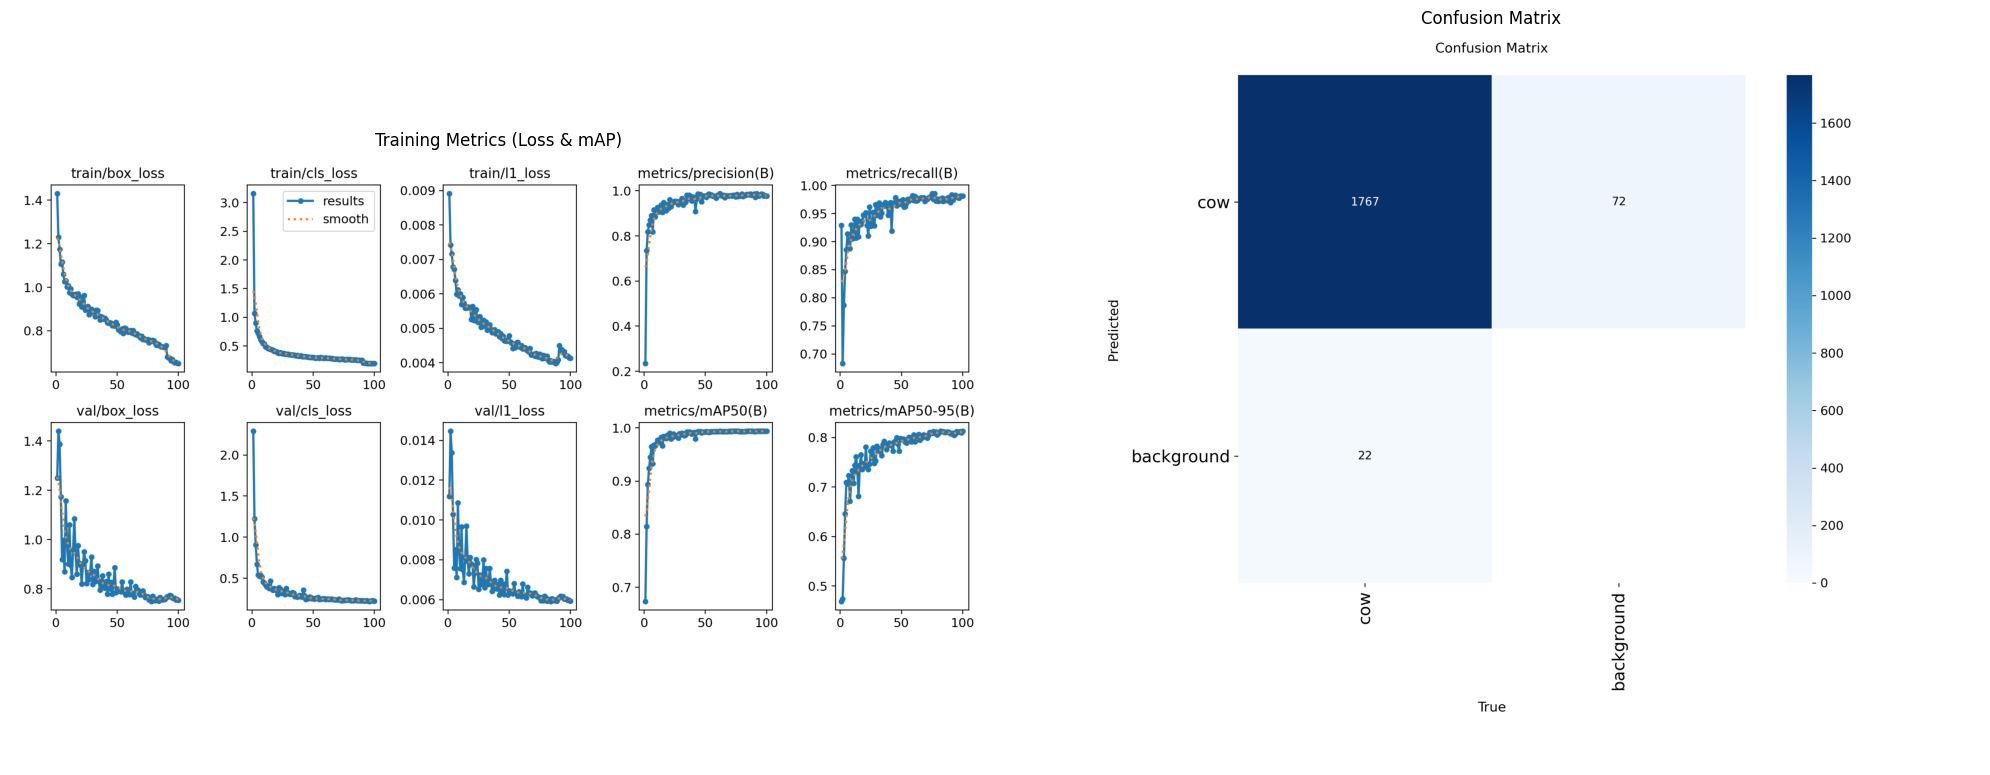


--- Phase 3: Visualizing Live Predictions ---

image 1/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test/image1000.jpg: 384x640 5 cows, 9.5ms
image 2/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test/image1001.jpg: 384x640 6 cows, 10.4ms
image 3/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test/image1002.jpg: 384x640 6 cows, 9.2ms
image 4/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test/image1003.jpg: 384x640 6 cows, 9.3ms
image 5/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test/image1004.jpg: 384x640 6 cows, 9.1ms
image 6/150 /kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target

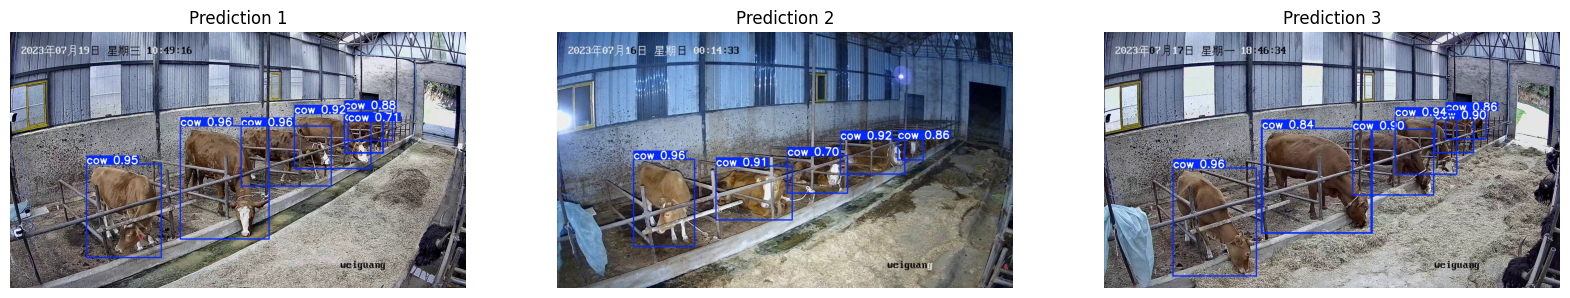

In [11]:
import os
import glob
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

print("--- Phase 1: Evaluating on the Test Split ---")

# 1. Load your newly trained "best" weights
best_model_path = '/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/models/cow_detector_v1/weights/best.pt'
model = YOLO(best_model_path)

# 2. Run official validation on the unseen 'test' folder
# The model knows where the test data is because it reads your bovine_data.yaml
metrics = model.val(
    data='/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/data/bovine_data.yaml', 
    split='test'
)

print(f"Test mAP50: {metrics.box.map50:.4f}")
print(f"Test mAP50-95: {metrics.box.map:.4f}")

print("\n--- Phase 2: Displaying Training Graphs ---")

# 3. Show the training results and confusion matrix directly in the notebook
run_dir = '/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/models/cow_detector_v1'

results_img = os.path.join(run_dir, 'results.png')
cm_img = os.path.join(run_dir, 'confusion_matrix.png')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

if os.path.exists(results_img):
    axes[0].imshow(cv2.cvtColor(cv2.imread(results_img), cv2.COLOR_BGR2RGB))
    axes[0].set_title('Training Metrics (Loss & mAP)')
    axes[0].axis('off')
    
if os.path.exists(cm_img):
    axes[1].imshow(cv2.cvtColor(cv2.imread(cm_img), cv2.COLOR_BGR2RGB))
    axes[1].set_title('Confusion Matrix')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n--- Phase 3: Visualizing Live Predictions ---")

# 4. Run inference on real images from the test folder
test_images_dir = '/kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Target detection dataset/Target detection dataset/images/test'

# Run prediction mode (no labels required, just visual output)
results = model.predict(
    source=test_images_dir, 
    save=True,      # Saves the images with boxes drawn
    imgsz=640,
    conf=0.5,       # Only show boxes it is 50%+ confident about
    max_det=20      # Max 20 cows per frame
)

# 5. Display the first 3 predicted images
predict_dir = results[0].save_dir # This is where Ultralytics saved the output
pred_images = glob.glob(os.path.join(predict_dir, '*.jpg'))[:3]

if pred_images:
    fig, axes = plt.subplots(1, len(pred_images), figsize=(20, 6))
    for i, img_path in enumerate(pred_images):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Prediction {i+1}")
    plt.show()

# The Behavior Classifier. 

In [12]:
import cv2
import os
import shutil
import random

# --- CONFIGURATION ---
SOURCE_DATA_DIR = '/kaggle/input/datasets/lucyfirst/beef-cattle-behavior-data-set/Category Videos/cows' 
OUTPUT_FRAMES_DIR = '/kaggle/working/behavior_classification_dataset'

# We increased this to 200 to give the model enough data to learn, 
# while keeping it balanced so 'drink' and 'ruminate' have equal weighting.
MAX_VIDEOS_PER_CATEGORY = 200  

VALIDATION_SPLIT = 0.2 
FRAME_EXTRACTION_INTERVAL = 30 # Assuming 30fps, this extracts 1 frame per second

# --- SCRIPT LOGIC ---
def extract_frames_from_labeled_videos():
    if not os.path.exists(SOURCE_DATA_DIR):
        print(f"FATAL ERROR: The source directory '{SOURCE_DATA_DIR}' was not found.")
        return
        
    CLASSES = [d for d in os.listdir(SOURCE_DATA_DIR) if os.path.isdir(os.path.join(SOURCE_DATA_DIR, d)) and d != 'cows']
    
    # 1. Create the Ultralytics-compliant directory structure (train and val)
    if os.path.exists(OUTPUT_FRAMES_DIR):
        shutil.rmtree(OUTPUT_FRAMES_DIR)
    os.makedirs(OUTPUT_FRAMES_DIR)
    
    # Fixed: YOLO strictly requires the folder to be named 'val', not 'validation'
    for split in ['train', 'val']: 
        for class_name in CLASSES:
            os.makedirs(os.path.join(OUTPUT_FRAMES_DIR, split, class_name), exist_ok=True)
            
    print(f"YOLO-compliant output directory created at: {OUTPUT_FRAMES_DIR}")
    
    # 2. Iterate and process videos
    for class_name in CLASSES:
        print(f"\n--- Processing class: {class_name} ---")
        class_dir = os.path.join(SOURCE_DATA_DIR, class_name)
        
        video_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.mp4', '.avi', '.mov'))]
        
        # Take a balanced subset to prevent class imbalance
        video_files_subset = video_files[:MAX_VIDEOS_PER_CATEGORY]
        
        # 3. Video-level splitting to prevent Data Leakage
        random.shuffle(video_files_subset)
        split_index = int(len(video_files_subset) * (1 - VALIDATION_SPLIT))
        train_videos = video_files_subset[:split_index]
        val_videos = video_files_subset[split_index:]

        print(f"Splitting into {len(train_videos)} train videos and {len(val_videos)} val videos.")

        for video_filename in train_videos:
            extract_frames(video_filename, class_name, class_dir, 'train')

        for video_filename in val_videos:
            extract_frames(video_filename, class_name, class_dir, 'val')
            
    print("\n--- Preprocessing complete! Ready for YOLO26-cls Training ---")

def extract_frames(video_filename, class_name, class_dir, split_name):
    video_path = os.path.join(class_dir, video_filename)
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return

    frame_count = 0
    saved_frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret: break 
        
        if frame_count % FRAME_EXTRACTION_INTERVAL == 0:
            frame_filename = f"{os.path.splitext(video_filename)[0]}_f{saved_frame_count}.jpg"
            output_path = os.path.join(OUTPUT_FRAMES_DIR, split_name, class_name, frame_filename)
            cv2.imwrite(output_path, frame)
            saved_frame_count += 1
            
        frame_count += 1
        
    cap.release()

# Run the pipeline
extract_frames_from_labeled_videos()

YOLO-compliant output directory created at: /kaggle/working/behavior_classification_dataset

--- Processing class: stand ---
Splitting into 160 train videos and 40 val videos.

--- Processing class: drink ---
Splitting into 160 train videos and 40 val videos.

--- Processing class: eat ---
Splitting into 160 train videos and 40 val videos.

--- Processing class: lie ---
Splitting into 160 train videos and 40 val videos.

--- Processing class: ruminate ---
Splitting into 160 train videos and 40 val videos.

--- Preprocessing complete! Ready for YOLO26-cls Training ---


In [14]:
from ultralytics import YOLO

print("Initializing YOLO26 Edge-Optimized Classifier...")

# Load the pretrained YOLO26 Nano classification model
model = YOLO('yolo26n-cls.pt') 

# Train the classification model directly on the folder structure
results = model.train(
    data='/kaggle/working/behavior_classification_dataset', 
    epochs=100,                  # 50 epochs is a solid baseline for classification
    imgsz=224,                  # Standard resolution for YOLO-cls models
    batch=32,                   # Larger batch size since imgsz is small
    device=0,                   # T4 GPU
    project='/kaggle/working/BoviTrack-RealTime-Behavior-Tracking/models',
    name='behavior_classifier_v1',
    patience=15,                # Stop early if no improvement
    half=True                   # FP16 precision
)

print("\nClassification Training Complete. Model saved to /kaggle/working/BoviTrack-RealTime-Behavior-Tracking/models/behavior_classifier_v1")

Initializing YOLO26 Edge-Optimized Classifier...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/behavior_classification_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, 